# Imports

In [79]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import matplotlib.dates as mdates
import warnings
warnings.simplefilter("ignore")

# Load Dataset

In [70]:
df = pd.read_csv("Data/uniswap_v3.csv.gz")
df

,amount0,amount1,amountUSD,id,logIndex,origin,recipient,sender,sqrtPriceX96,tick,...,owner,tickLower,tickUpper,transaction.blockNumber,transaction.gasPrice,transaction.gasUsed,transaction.id,transaction.timestamp,price_1_per_0,t
0,-10.000000,0.003023,9.998842,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,264,0x12f82b9929c92fdf853d9d9b076c32909f25718a,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,1377282103516700331802368117587827,195275.0,...,NaN,NaN,NaN,24257914,1.033162e+09,0.0,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,1768694459,3.021771e+08,59.0
1,0.002699,-8.929703,8.927690,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,221,0x3bae26c9ee93467619ebb3d0dbc3d052243cacb4,0xcdb49866c473bfd0a4dbf64e48d7db2cd31796df,0x8793c6aa63cc96c955da4906f628dc09cd595dc8,4558100686673991521600072,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,1768694471,3.309649e-09,71.0
2,0.001749,-5.785837,5.784533,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,288,0x19a4cc064ba710a9ce97499f3c659288bb2ad2dd,0x0b02428e7c2c24ccf64426e637aee0c879bd1860,0x40753445cc591925b49a00d5d727a4fd7049d800,4558100464914553349295265,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,1768694471,3.309649e-09,71.0
3,0.000000,0.000000,0.000000,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,394,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,0xc36442b4a4522e871399cd717abdd847ab11fe88,0.0,1.0,24257915,NaN,NaN,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,1768694471,NaN,71.0
4,0.000000,0.000000,0.000000,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,311,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,0xc36442b4a4522e871399cd717abdd847ab11fe88,0.0,1.0,24257916,NaN,NaN,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,1768694483,NaN,83.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468187,-534.128831,0.267508,533.992405,0xa53e5d5a9679f2fa4a611cf59ff64e3a674292d46b28...,274,0x0426e3cf11caf15ffcb14c371314359934b6b2ce,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,1772624560944410379271804609024497,200322.0,...,NaN,NaN,NaN,24472822,1.030892e+09,0.0,0xa53e5d5a9679f2fa4a611cf59ff64e3a674292d46b28...,1771286363,5.005402e+08,2591963.0
468188,-532.915750,0.266901,532.780087,0xa53e5d5a9679f2fa4a611cf59ff64e3a674292d46b28...,279,0x0426e3cf11caf15ffcb14c371314359934b6b2ce,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,1772626066969204442031536473429827,200322.0,...,NaN,NaN,NaN,24472822,1.030892e+09,0.0,0xa53e5d5a9679f2fa4a611cf59ff64e3a674292d46b28...,1771286363,5.005402e+08,2591963.0
468189,-0.002684,5.366980,5.362012,0x0631fc60f6b586858de1e3ff18a83c824a6d66aa44e4...,21,0xee608a97b040c341c85afad3e1dd69251eb87035,0x282886d79c7495df43ad3d734b636644a0a3f320,0x282886d79c7495df43ad3d734b636644a0a3f320,3541742137642908127256565,-200320.0,...,NaN,NaN,NaN,24472824,3.114259e+07,0.0,0x0631fc60f6b586858de1e3ff18a83c824a6d66aa44e4...,1771286387,1.998241e-09,2591987.0
468190,-9990.996826,9997.000000,9993.998413,0x05be705aceadfa9f73d35fd8d55e094bf57a291b2fc5...,233,0x43370188473a398394e4ba4a7c7cbb2c6265e22a,0x47f2c56286f81d9b5e438ea7d60eca59b6ec1c69,0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45,79248005948958442658832787685,5.0,...,NaN,NaN,NaN,24472825,5.165245e+07,0.0,0x05be705aceadfa9f73d35fd8d55e094bf57a291b2fc5...,1771286399,1.000500e+00,2591999.0


# Perform Data Analysis

In [71]:
print(df.dtypes)

amount0                    float64
amount1                    float64
amountUSD                  float64
id                          object
logIndex                     int64
origin                      object
recipient                   object
sender                      object
sqrtPriceX96                object
tick                       float64
timestamp                   object
pool                        object
event_type                  object
amount                     float64
owner                       object
tickLower                  float64
tickUpper                  float64
transaction.blockNumber      int64
transaction.gasPrice       float64
transaction.gasUsed        float64
transaction.id              object
transaction.timestamp        int64
price_1_per_0              float64
t                          float64
dtype: object


In [72]:
df.columns

Index(['amount0', 'amount1', 'amountUSD', 'id', 'logIndex', 'origin',
       'recipient', 'sender', 'sqrtPriceX96', 'tick', 'timestamp', 'pool',
       'event_type', 'amount', 'owner', 'tickLower', 'tickUpper',
       'transaction.blockNumber', 'transaction.gasPrice',
       'transaction.gasUsed', 'transaction.id', 'transaction.timestamp',
       'price_1_per_0', 't'],
      dtype='object')

In [73]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

In [74]:
swaps = df[df['event_type'] == 'swap']
mints = df[df['event_type'] == 'mint']
burns = df[df['event_type'] == 'burn']

In [75]:
df['event_type'].value_counts()

event_type
swap    448989
burn     10036
mint      9167
Name: count, dtype: int64

Should investigate the active liquidity of the pool and plot the liquidity profile

In [76]:
df[['amountUSD','amount0','amount1']].describe()

,amountUSD,amount0,amount1
count,4.681920e+05,4.681920e+05,4.681920e+05
mean,3.233954e+04,5.362365e+03,3.767927e+03
std,2.054228e+05,1.191563e+05,7.520230e+04
min,0.000000e+00,-9.754211e+06,-6.000966e+06
25%,1.531563e+02,-5.198416e+01,-7.582806e+00
50%,1.915756e+03,7.560000e-06,2.400027e-03
75%,8.548032e+03,1.088969e+02,1.409878e+01
max,2.582459e+07,5.999400e+06,5.384288e+06


<Axes: title={'center': 'Daily swap volume (USD)'}, xlabel='date'>

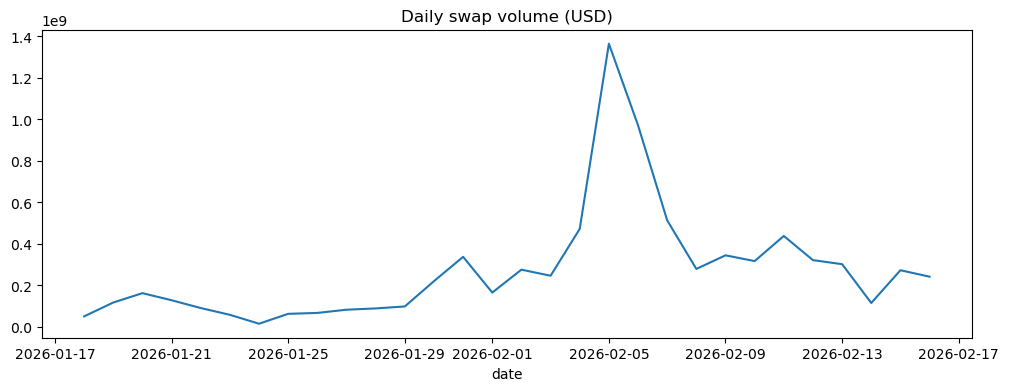

In [77]:
daily = swaps.groupby('date')['amountUSD'].sum()
daily.plot(title='Daily swap volume (USD)', figsize=(12,4))

<Axes: title={'center': 'Price over time'}, xlabel='timestamp'>

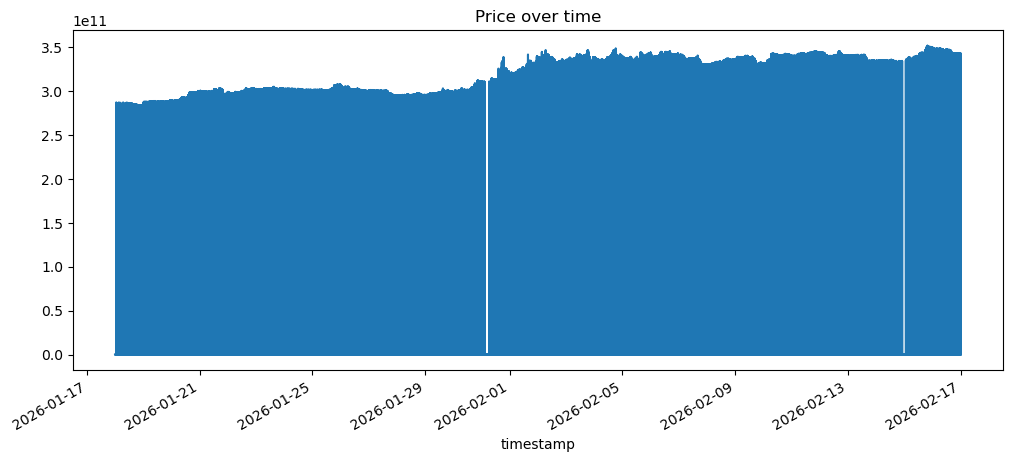

In [ ]:
swaps['price'] = 1.0001 ** swaps['tick'] #doit le changer en précisant que je suis sur uniswapV3
swaps.set_index('timestamp')['price'].plot(title='Price over time', figsize=(12,5))

,amount0,amount1,amountUSD,id,logIndex,origin,recipient,sender,sqrtPriceX96,tick,...,tickUpper,transaction.blockNumber,transaction.gasPrice,transaction.gasUsed,transaction.id,transaction.timestamp,price_1_per_0,t,date,hour
0,-10.000000,0.003023,9.998842,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,264,0x12f82b9929c92fdf853d9d9b076c32909f25718a,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,1377282103516700331802368117587827,195275.0,...,NaN,24257914,1.033162e+09,0.0,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,1768694459,3.021771e+08,59.0,2026-01-18,0
1,0.002699,-8.929703,8.927690,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,221,0x3bae26c9ee93467619ebb3d0dbc3d052243cacb4,0xcdb49866c473bfd0a4dbf64e48d7db2cd31796df,0x8793c6aa63cc96c955da4906f628dc09cd595dc8,4558100686673991521600072,-195274.0,...,NaN,24257915,3.502565e+07,0.0,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,1768694471,3.309649e-09,71.0,2026-01-18,0
2,0.001749,-5.785837,5.784533,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,288,0x19a4cc064ba710a9ce97499f3c659288bb2ad2dd,0x0b02428e7c2c24ccf64426e637aee0c879bd1860,0x40753445cc591925b49a00d5d727a4fd7049d800,4558100464914553349295265,-195274.0,...,NaN,24257915,3.502565e+07,0.0,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,1768694471,3.309649e-09,71.0,2026-01-18,0
3,0.000000,0.000000,0.000000,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,394,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,1.0,24257915,NaN,NaN,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,1768694471,NaN,71.0,2026-01-18,0
4,0.000000,0.000000,0.000000,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,311,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,1.0,24257916,NaN,NaN,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,1768694483,NaN,83.0,2026-01-18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468185,0.277490,-0.000139,0.277280,0x0279c3dcdccb3a02e1c19482678c4b8de107518c23f4...,152,0x6e2c8549ecc8615f14351889066a4ef196a688cd,0xaf682de1f2e6f710731121a05a44cb3c1b511f7d,0xaf682de1f2e6f710731121a05a44cb3c1b511f7d,1772621637320892030389802672486831,200322.0,...,NaN,24472822,3.089157e+07,0.0,0x0279c3dcdccb3a02e1c19482678c4b8de107518c23f4...,1771286363,5.005402e+08,2591963.0,2026-02-16,23
468186,-500.415167,0.250623,500.286940,0x6d3677d6061453a14149725d60942869023d47108275...,232,0xd2adf24253056d45731a8561749fc9b2ffa4fe19,0xf48a3f7c0575c85cf4529aa220caf3c055773f1c,0xf48a3f7c0575c85cf4529aa220caf3c055773f1c,1772623051494004475469658630338784,200322.0,...,NaN,24472822,1.000000e+08,0.0,0x6d3677d6061453a14149725d60942869023d47108275...,1771286363,5.005402e+08,2591963.0,2026-02-16,23
468189,-0.002684,5.366980,5.362012,0x0631fc60f6b586858de1e3ff18a83c824a6d66aa44e4...,21,0xee608a97b040c341c85afad3e1dd69251eb87035,0x282886d79c7495df43ad3d734b636644a0a3f320,0x282886d79c7495df43ad3d734b636644a0a3f320,3541742137642908127256565,-200320.0,...,NaN,24472824,3.114259e+07,0.0,0x0631fc60f6b586858de1e3ff18a83c824a6d66aa44e4...,1771286387,1.998241e-09,2591987.0,2026-02-16,23
468190,-9990.996826,9997.000000,9993.998413,0x05be705aceadfa9f73d35fd8d55e094bf57a291b2fc5...,233,0x43370188473a398394e4ba4a7c7cbb2c6265e22a,0x47f2c56286f81d9b5e438ea7d60eca59b6ec1c69,0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45,79248005948958442658832787685,5.0,...,NaN,24472825,5.165245e+07,0.0,0x05be705aceadfa9f73d35fd8d55e094bf57a291b2fc5...,1771286399,1.000500e+00,2591999.0,2026-02-16,23


## Events Analysis

In [103]:
lp_events = df[df['event_type'].isin(['mint', 'burn'])].copy()
lp_events['timestamp'] = pd.to_datetime(lp_events['timestamp'])
lp_events = lp_events.sort_values('timestamp')

In [104]:
lp_events['signed_usd'] = np.where(
    lp_events['event_type'] == 'mint',
    lp_events['amountUSD'],
    -lp_events['amountUSD']
)
lp_events['signed_amount0'] = np.where(
    lp_events['event_type'] == 'mint',
    lp_events['amount0'],
    -lp_events['amount0']
)
lp_events['signed_amount1'] = np.where(
    lp_events['event_type'] == 'mint',
    lp_events['amount1'],
    -lp_events['amount1']
)

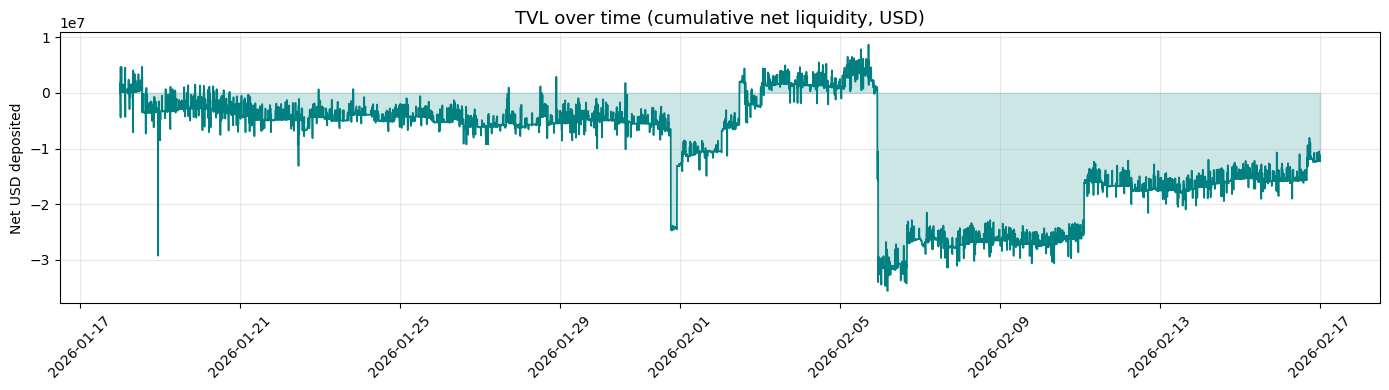

In [105]:
lp_events_sorted = lp_events.sort_values('timestamp')
lp_events_sorted['tvl_usd'] = lp_events_sorted['signed_usd'].cumsum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(lp_events_sorted['timestamp'], lp_events_sorted['tvl_usd'], alpha=0.2, color='teal')
ax.plot(lp_events_sorted['timestamp'], lp_events_sorted['tvl_usd'], linewidth=1.2, color='teal')
ax.set_title("TVL over time (cumulative net liquidity, USD)", fontsize=13)
ax.set_ylabel("Net USD deposited")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

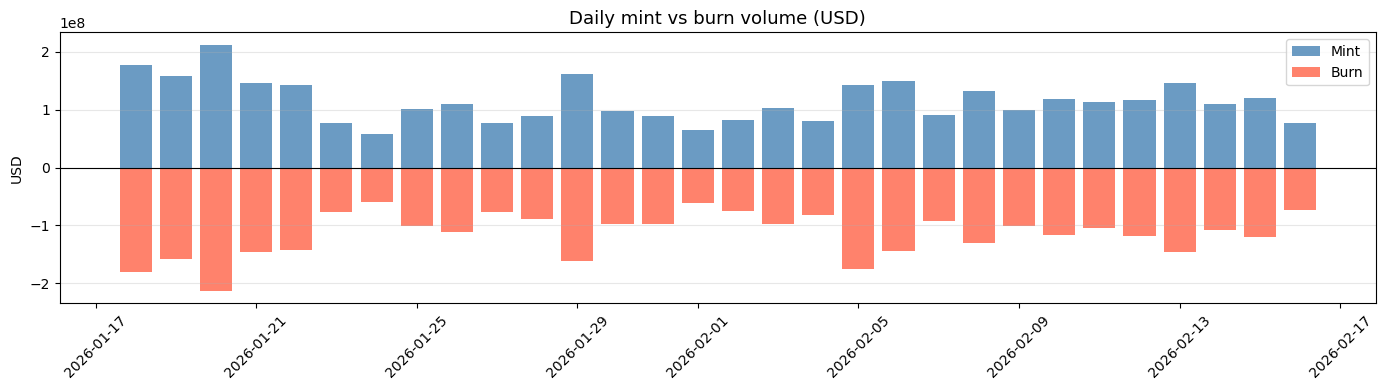

In [106]:
lp_events['date'] = lp_events['timestamp'].dt.date

daily = lp_events.groupby(['date', 'event_type'])['amountUSD'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
if 'mint' in daily.columns:
    ax.bar(daily.index, daily['mint'], label='Mint', color='steelblue', alpha=0.8)
if 'burn' in daily.columns:
    ax.bar(daily.index, -daily['burn'], label='Burn', color='tomato', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Daily mint vs burn volume (USD)", fontsize=13)
ax.set_ylabel("USD")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Tick range width statistics:
count    9.167000e+03
mean     1.744070e+04
std      1.633579e+05
min      1.000000e+00
25%      1.000000e+01
50%      3.600000e+02
75%      2.845000e+03
max      1.774544e+06
Name: tick_width, dtype: float64


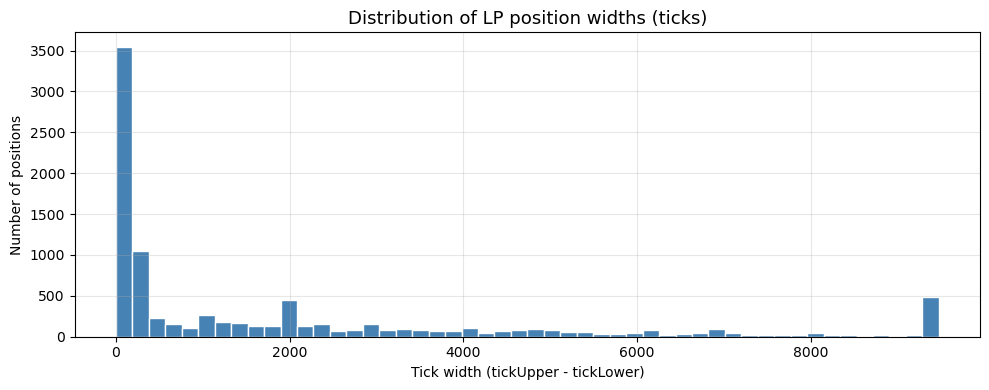

In [ ]:
mints = lp_events[lp_events['event_type'] == 'mint'].copy()

mints['tick_width'] = mints['tickUpper'] - mints['tickLower']

mints['price_lower'] = 1.0001 ** mints['tickLower']
mints['price_upper'] = 1.0001 ** mints['tickUpper']

print("Tick range width statistics:")
print(mints['tick_width'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
mints['tick_width'].clip(upper=mints['tick_width'].quantile(0.95)).hist(
    bins=50, ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title("Distribution of LP position widths (ticks)", fontsize=13)
ax.set_xlabel("Tick width (tickUpper - tickLower)")
ax.set_ylabel("Number of positions")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

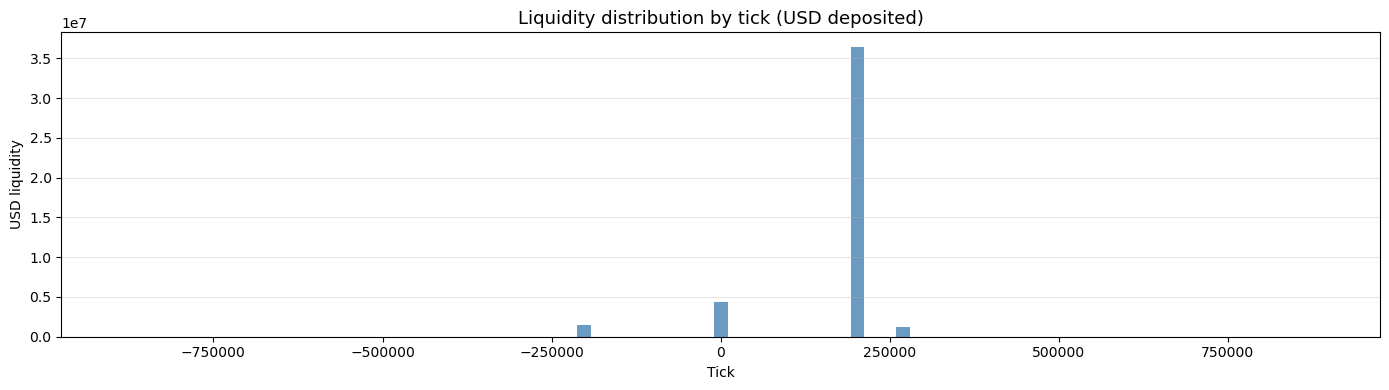

In [ ]:
tick_min = mints['tickLower'].min()
tick_max = mints['tickUpper'].max()
bins = np.linspace(tick_min, tick_max, 80)

heatmap = np.zeros(len(bins) - 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

for _, row in mints.iterrows():
    mask = (bin_centers >= row['tickLower']) & (bin_centers <= row['tickUpper'])
    if mask.any():
        heatmap[mask] += row['amountUSD'] / mask.sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(bin_centers, heatmap, width=(bins[1]-bins[0])*0.9, color='steelblue', alpha=0.8)
ax.set_title("Liquidity distribution by tick (USD deposited)", fontsize=13)
ax.set_xlabel("Tick")
ax.set_ylabel("USD liquidity")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
id_col = 'owner' if lp_events['owner'].notna().sum() > 0 else 'sender'

lp_summary = (
    lp_events.groupby([id_col, 'event_type'])['amountUSD']
    .sum()
    .unstack(fill_value=0)
    .rename(columns={'mint': 'total_minted_usd', 'burn': 'total_burned_usd'})
)

for col in ['total_minted_usd', 'total_burned_usd']:
    if col not in lp_summary.columns:
        lp_summary[col] = 0

lp_summary['net_usd'] = (
    lp_summary['total_minted_usd'] - lp_summary['total_burned_usd']
)

lp_summary['n_mints'] = (
    lp_events[lp_events['event_type']=='mint']
    .groupby(id_col)
    .size()
)

lp_summary['n_burns'] = (
    lp_events[lp_events['event_type']=='burn']
    .groupby(id_col)
    .size()
)

lp_summary['withdrawal_rate'] = (
    lp_summary['total_burned_usd'] /
    lp_summary['total_minted_usd'].replace(0, 1)
).clip(0, 1)

lp_summary = lp_summary.fillna(0).sort_values('total_minted_usd', ascending=False)

print(f"Total unique LPs: {len(lp_summary)}")
print(f"\nTop 10 LPs by total minted USD:")
print(lp_summary.head(10).to_string())

Total unique LPs: 21

Top 10 LPs by total minted USD:
event_type                                  total_burned_usd  total_minted_usd       net_usd  n_mints  n_burns  withdrawal_rate
owner                                                                                                                          
0x1f2f10d1c40777ae1da742455c65828ff36df387      3.006986e+09      3.006886e+09 -9.977361e+04   1820.0     1820         1.000000
0xc36442b4a4522e871399cd717abdd847ab11fe88      2.595094e+08      2.476368e+08 -1.187259e+07   7187.0     8041         1.000000
0x28ac01d4790ed04b378ca32c90e443b3cb6358cd      1.615896e+08      1.616143e+08  2.473631e+04     50.0       50         0.999847
0x263dc5b7b0f2e433b03964f6288344ef8dc952e4      9.211922e+06      9.201997e+06 -9.924674e+03     12.0       12         1.000000
0x6dc71298ce1b61ba4c83d5cdf4b3b1e9aa558a7f      8.947558e+06      8.941071e+06 -6.486881e+03     15.0       15         1.000000
0xc30f6ee36a1746dd71c7e81529eeae7ce2f52252      4.

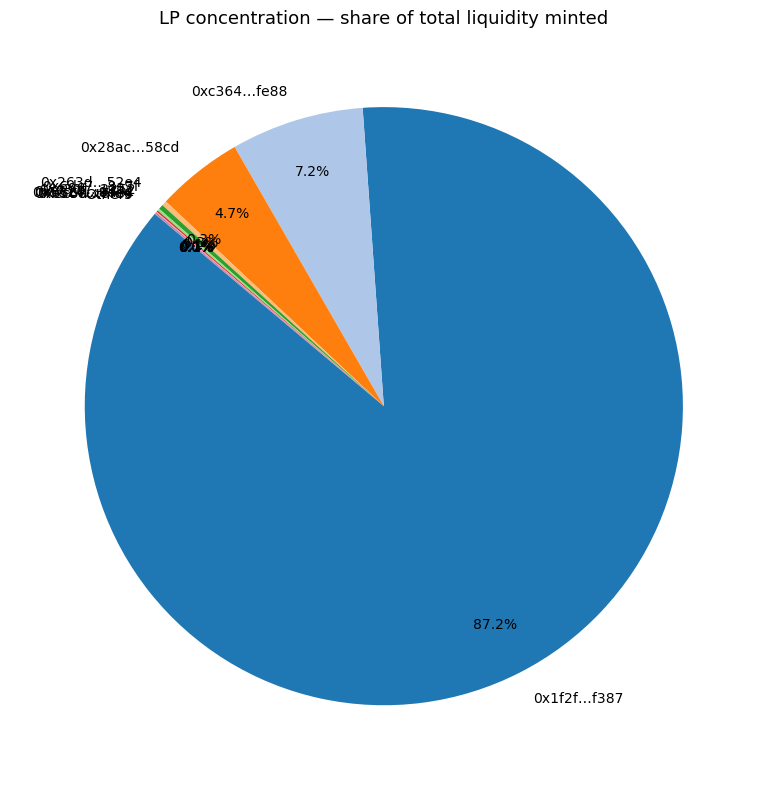

In [116]:
top_n = 10
top_lps = lp_summary['total_minted_usd'].head(top_n)
others  = lp_summary['total_minted_usd'].iloc[top_n:].sum()

labels = [f"{addr[:6]}…{addr[-4:]}" for addr in top_lps.index] + ['Others']
sizes  = list(top_lps.values) + [others]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    startangle=140, pctdistance=0.82,
    colors=plt.cm.tab20.colors[:len(sizes)]
)
ax.set_title("LP concentration — share of total liquidity minted", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
mints_pos = mints[[id_col, 'tickLower', 'tickUpper', 'amountUSD', 'timestamp']].copy()
mints_pos.columns = [id_col, 'tickLower', 'tickUpper', 'mint_usd', 'mint_time']

burns = lp_events[lp_events['event_type'] == 'Burn'].copy()
burns_pos = burns[[id_col, 'tickLower', 'tickUpper', 'amountUSD', 'timestamp']].copy()
burns_pos.columns = [id_col, 'tickLower', 'tickUpper', 'burn_usd', 'burn_time']

positions = mints_pos.merge(burns_pos, on=[id_col, 'tickLower', 'tickUpper'], how='left')
positions['duration_days'] = (
    positions['burn_time'] - positions['mint_time']
).dt.total_seconds() / 86400

closed = positions.dropna(subset=['burn_time'])
open_  = positions[positions['burn_time'].isna()]

print(f"Closed positions: {len(closed)}")
print(f"Still open positions: {len(open_)}")
if len(closed) > 0:
    print(f"\nMedian holding duration: {closed['duration_days'].median():.1f} days")
    print(f"Mean holding duration:   {closed['duration_days'].mean():.1f} days")

    fig, ax = plt.subplots(figsize=(10, 4))
    closed['duration_days'].clip(upper=closed['duration_days'].quantile(0.95)).hist(
        bins=40, ax=ax, color='mediumseagreen', edgecolor='white'
    )
    ax.set_title("LP position holding duration (days)", fontsize=13)
    ax.set_xlabel("Days open")
    ax.set_ylabel("Number of positions")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Closed positions: 0
Still open positions: 9167
